In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from mpl_toolkits.axes_grid1 import make_axes_locatable
import time
from matplotlib.lines import Line2D
import geopandas as gpd
from sklearn.metrics.pairwise import haversine_distances
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.gridspec as gridspec
import matplotlib as mpl
import rasterio as rio
from rasterio.plot import show
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import Normalize
from geo_northarrow import add_north_arrow

In [ ]:
dir_top_maxent = "/your_path/Documents/GitHub/r_chagasM/output/pixel_buffer_off"
dir_top_rf = "/your_path/Documents/GitHub/r_chagasM/output/rf/pixel_buffer_off"
dir_diff = "/your_path/Documents/GitHub/r_chagasM/output/figures/final_plot/difference"
dir_saving_plot_path = '/your_path/Documents/GitHub/r_chagasM/output/figures/final_plot/plots'
#sp_rarefied_name_list_full = ['T. sanguisuga','T. rubida',' T. recurva','T. protracta','T. mexicana','T. mazzottii','T. neotomae','T. longipennis',' P. lecticularia',' T. indictiva','T. gerstaeckeri','T. dimidiata']
#label_list = ['A','B','C','D','E','F','G','H','I','J','K','L','M','N']
#bug_name_list = ["sanguisuga","rubida","recurva","protracta","mexicana","mazzottii","neotomae","longipennis","lecticularia","indictiva","gerstaeckeri","dimidiata"]
bug_name_list = ['sanguisuga','dimidiata','gerstaeckeri','protracta','longipennis','rubida','pallidipennis','barberi','mexicana','lecticularia','recurva','mazzottii','hirsuta','indictiva']
bug_short_name_list=['san','dim','ger','pro','lon','rub','pal','bar','mex','lec','rec','maz','hir','ind']
sp_rarefied_name_list_full = ['T. sanguisuga','T. dimidiata','T. gerstaeckeri','T. protracta','T. longipennis','T. rubida','M. pallidipennis','T. barberi','T. mexicana','P. lecticularia','T. recurva','T. mazzottii','P. hirsuta','T. indictiva']
method_name_list = ["pixel_nobuffer_off","pixel_nobuffer_on","pixel_buffer_off","pixel_buffer_on","grid_nobuffer_off","grid_nobuffer_on","grid_buffer_off","grid_buffer_on"]
bug_name_list_c = ['San','Dim','Ger','Pro','Lon','Rub','Pal','Bar','Mex','Lec','Rec','Maz','Hir','Ind']
label_list = ['A','B','C','D','E','F','G','H','I','J','K','L','M','N']

In [3]:
old_blue = plt.get_cmap('Blues')

# Create a new colormap that goes from white to the 'Blues' colormap
newcolors_1 = old_blue(np.linspace(0, 1, 256))
newcolors_1[0, :] = np.array([1, 1, 1, 1])  # Set the first color to white
new_blue = LinearSegmentedColormap.from_list('Custom Blues', newcolors_1)

old_red = plt.get_cmap('Reds')

# Create a new colormap that goes from white to the 'Blues' colormap
newcolors_2 = old_red(np.linspace(0, 1, 256))
newcolors_2[0, :] = np.array([1, 1, 1, 1])  # Set the first color to white
new_red = LinearSegmentedColormap.from_list('Custom Reds', newcolors_2)


In [6]:
# # Enable LaTeX rendering in Matplotlib
# this_fontsize = 44
# xlim = [-180,-10]
# ylim = [5,85]
# bug_name_list = ['San']#,'Rub','Rec','Pro','Mex','Maz','Neo','Lon','Lec','Ind','Ger','Dim']
# raster_save_list = ["historical_predict_allinput_","ssp126_predict_allinput_","ssp245_predict_allinput_","ssp370_predict_allinput_","ssp585_predict_allinput_"]
# diff_raster_save_list = ["diff_historical.tif","diff_ssp126.tif","diff_ssp245.tif","diff_ssp370.tif","diff_ssp585.tif"]
# for j in range(len(bug_name_list)):

#     this_bug = bug_name_list[j]
#     print(this_bug)
#     fig, ax = plt.subplots(5,4, figsize=(40,30))
#     plt.rcParams['text.usetex'] = True
#     for i in range(20):
        
#         ax_0 = i // 4
#         ax_1 = i % 4

        
#         world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
#         world.boundary.plot(ax=ax[ax_0,ax_1], color = 'slategrey',linewidth=1,figsize=(6,5))


#         # maxent
#         if ax_1 == 0:
#             name_for_saving = dir_top_maxent + '/' + this_bug+"/result/output_raster/all_input/"+ raster_save_list[ax_0] + this_bug + '.tif'
#             predict_plot_final = rio.open(name_for_saving)
#             show(predict_plot_final,cmap=new_red,ax=ax[ax_0,ax_1],vmin=0, vmax=1)

#         # rf
#         if ax_1 == 1:
#             name_for_saving = dir_top_rf + '/' + this_bug+"/result/output_raster/all_input/"+ raster_save_list[ax_0] + this_bug + '.tif'
#             predict_plot_final = rio.open(name_for_saving)
#             show(predict_plot_final,cmap=new_red,ax=ax[ax_0,ax_1],vmin=0, vmax=1)

#         # difference + 
#         if ax_1 == 2:
#             name_for_saving = dir_diff + '/' + this_bug + '/'+ diff_raster_save_list[ax_0]
#             predict_plot_final = rio.open(name_for_saving)
#             show(predict_plot_final,cmap=new_red,ax=ax[ax_0,ax_1],vmin=0, vmax=1)

#         # difference - 
#         if ax_1 == 3:
#             name_for_saving = dir_diff + '/' + this_bug + '/'+ diff_raster_save_list[ax_0]
#             predict_plot_final = rio.open(name_for_saving)
#             show(predict_plot_final,cmap=new_blue,ax=ax[ax_0,ax_1],vmin=-1, vmax=0)
        
#         ax[ax_0,ax_1].set_aspect('equal')
#         ax[ax_0,ax_1].set_xlim(xlim)
#         ax[ax_0,ax_1].set_ylim(ylim)
#         ax[ax_0,ax_1].tick_params(left = False, right = False , labelleft = False ,labelbottom = False, bottom = False)
        
#     plt.gcf().text(0.08, 0.90, label_list[j] + ') ' + r'$\it{%s}$' % sp_rarefied_name_list_full[j], fontsize=this_fontsize,weight='bold')
#     plt.gcf().text(0.08, 0.80, '1) Historical', fontsize=this_fontsize)
#     plt.gcf().text(0.08, 0.65, '2) SSP1 RCP2.6', fontsize=this_fontsize)
#     plt.gcf().text(0.08, 0.50, '3) SSP2 RCP4.5', fontsize=this_fontsize)
#     plt.gcf().text(0.08, 0.35, '4) SSP3 RCP7.0', fontsize=this_fontsize)
#     plt.gcf().text(0.08, 0.20, '5) SSP5 RCP8.5', fontsize=this_fontsize)
#     plt.gcf().text(0.215, 0.90, 'a) MaxEnt ('+"$p_{m}$"+')', fontsize=this_fontsize)
#     plt.gcf().text(0.367, 0.90, 'b) Random Forest ('+"$p_{r}$"+')', fontsize=this_fontsize)
#     plt.gcf().text(0.505, 0.90, 'c) Positive Difference '+'$(p_{r}-p_{m})_+$', fontsize=this_fontsize)
#     plt.gcf().text(0.67, 0.90, 'd) Negative Difference '+'$(p_{r}-p_{m})_-$', fontsize=this_fontsize)
    
#     plt.subplots_adjust(hspace=0.015)
#     plt.subplots_adjust(wspace=-0.015)
#     plt.subplots_adjust(left=0.16,right=0.84)

#     diff_file_path = dir_diff +  '/' + this_bug + '/'+ "/sum_results.csv"   
#     diff_df = pd.read_csv(diff_file_path)
#     plt.gcf().text(0.85, 0.90, r'$(\overline{p_{r}}-\overline{p_{m}})/\overline{p_{m}}$', fontsize=this_fontsize)
#     plt.gcf().text(0.86, 0.80, '%.1f'%(100*(diff_df['sum_diff_raster_historical'])/diff_df['sum_maxent_raster_historical']) + '\%', fontsize=this_fontsize)
#     plt.gcf().text(0.86, 0.65, '%.1f'%(100*(diff_df['sum_diff_raster_ssp126'])/diff_df['sum_maxent_raster_ssp126']) + '\%', fontsize=this_fontsize)
#     plt.gcf().text(0.86, 0.50, '%.1f'%(100*(diff_df['sum_diff_raster_ssp245'])/diff_df['sum_maxent_raster_ssp245']) + '\%', fontsize=this_fontsize)
#     plt.gcf().text(0.86, 0.35, '%.1f'%(100*(diff_df['sum_diff_raster_ssp370'])/diff_df['sum_maxent_raster_ssp370']) + '\%', fontsize=this_fontsize)
#     plt.gcf().text(0.86, 0.20, '%.1f'%(100*(diff_df['sum_diff_raster_ssp585'])/diff_df['sum_maxent_raster_ssp585']) + '\%', fontsize=this_fontsize)
    
#     # # subplot for colorbar
#     ax2 =fig.add_axes([0.17,0.08,0.32,0.02])
#     cb2 = mpl.colorbar.ColorbarBase(ax2, orientation='horizontal', cmap='viridis')
#     cb2.set_label("$p_{m}$"+', '+"$p_{r}$", labelpad=0, size=this_fontsize-5)
#     cb2.ax.tick_params(labelsize=this_fontsize-10)
#     # # subplot for colorbar
#     norm3 = Normalize(vmin=0, vmax=1)
#     ax3 =fig.add_axes([0.515,0.08,0.14,0.02])
#     cb3 = mpl.colorbar.ColorbarBase(ax3, orientation='horizontal', cmap=new_red,norm=norm3)
#     cb3.set_label("$(p_{r}-p_{m})_+$", labelpad=0, size=this_fontsize-5)
#     cb3.ax.tick_params(labelsize=this_fontsize-10)
#     # # subplot for colorbar
#     norm4 = Normalize(vmin=-1, vmax=0)
#     ax4 =fig.add_axes([0.685,0.08,0.14,0.02])
#     cb4 = mpl.colorbar.ColorbarBase(ax4, orientation='horizontal', cmap=new_blue,norm=norm4)
#     cb4.set_label("$(p_{r}-p_{m})_-$", labelpad=0, size=this_fontsize-5)
#     cb4.ax.tick_params(labelsize=this_fontsize-10)
#     #'T. dimidiata','T. gerstaeckeri','T. protracta','T. sanguisuga'
#     #plt.savefig(dir_saving_plot_path+'/'+this_bug+'.png',dpi=100)
#     plt.clf()

/var/folders/dx/4fv665g177x973sw3f557wx80000gq/T/ipykernel_40949/2666207331.py:1: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


ind


/var/folders/dx/4fv665g177x973sw3f557wx80000gq/T/ipykernel_40949/2666207331.py:80: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  plt.gcf().text(0.86, 0.80, '%.1f'%(100*(diff_df['sum_diff_raster_historical'])/diff_df['sum_maxent_raster_historical']) + '\%', fontsize=this_fontsize)
/var/folders/dx/4fv665g177x973sw3f557wx80000gq/T/ipykernel_40949/2666207331.py:81: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  plt.gcf().text(0.86, 0.65, '%.1f'%(100*(diff_df['sum_diff_raster_ssp126'])/diff_df['sum_maxent_raster_ssp126']) + '\%', fontsize=this_fontsize)
/var/folders/dx/4fv665g177x973sw3f557wx80000gq/T/ipykernel_40949/2666207331.py:82: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  plt.gcf().text(0.86,

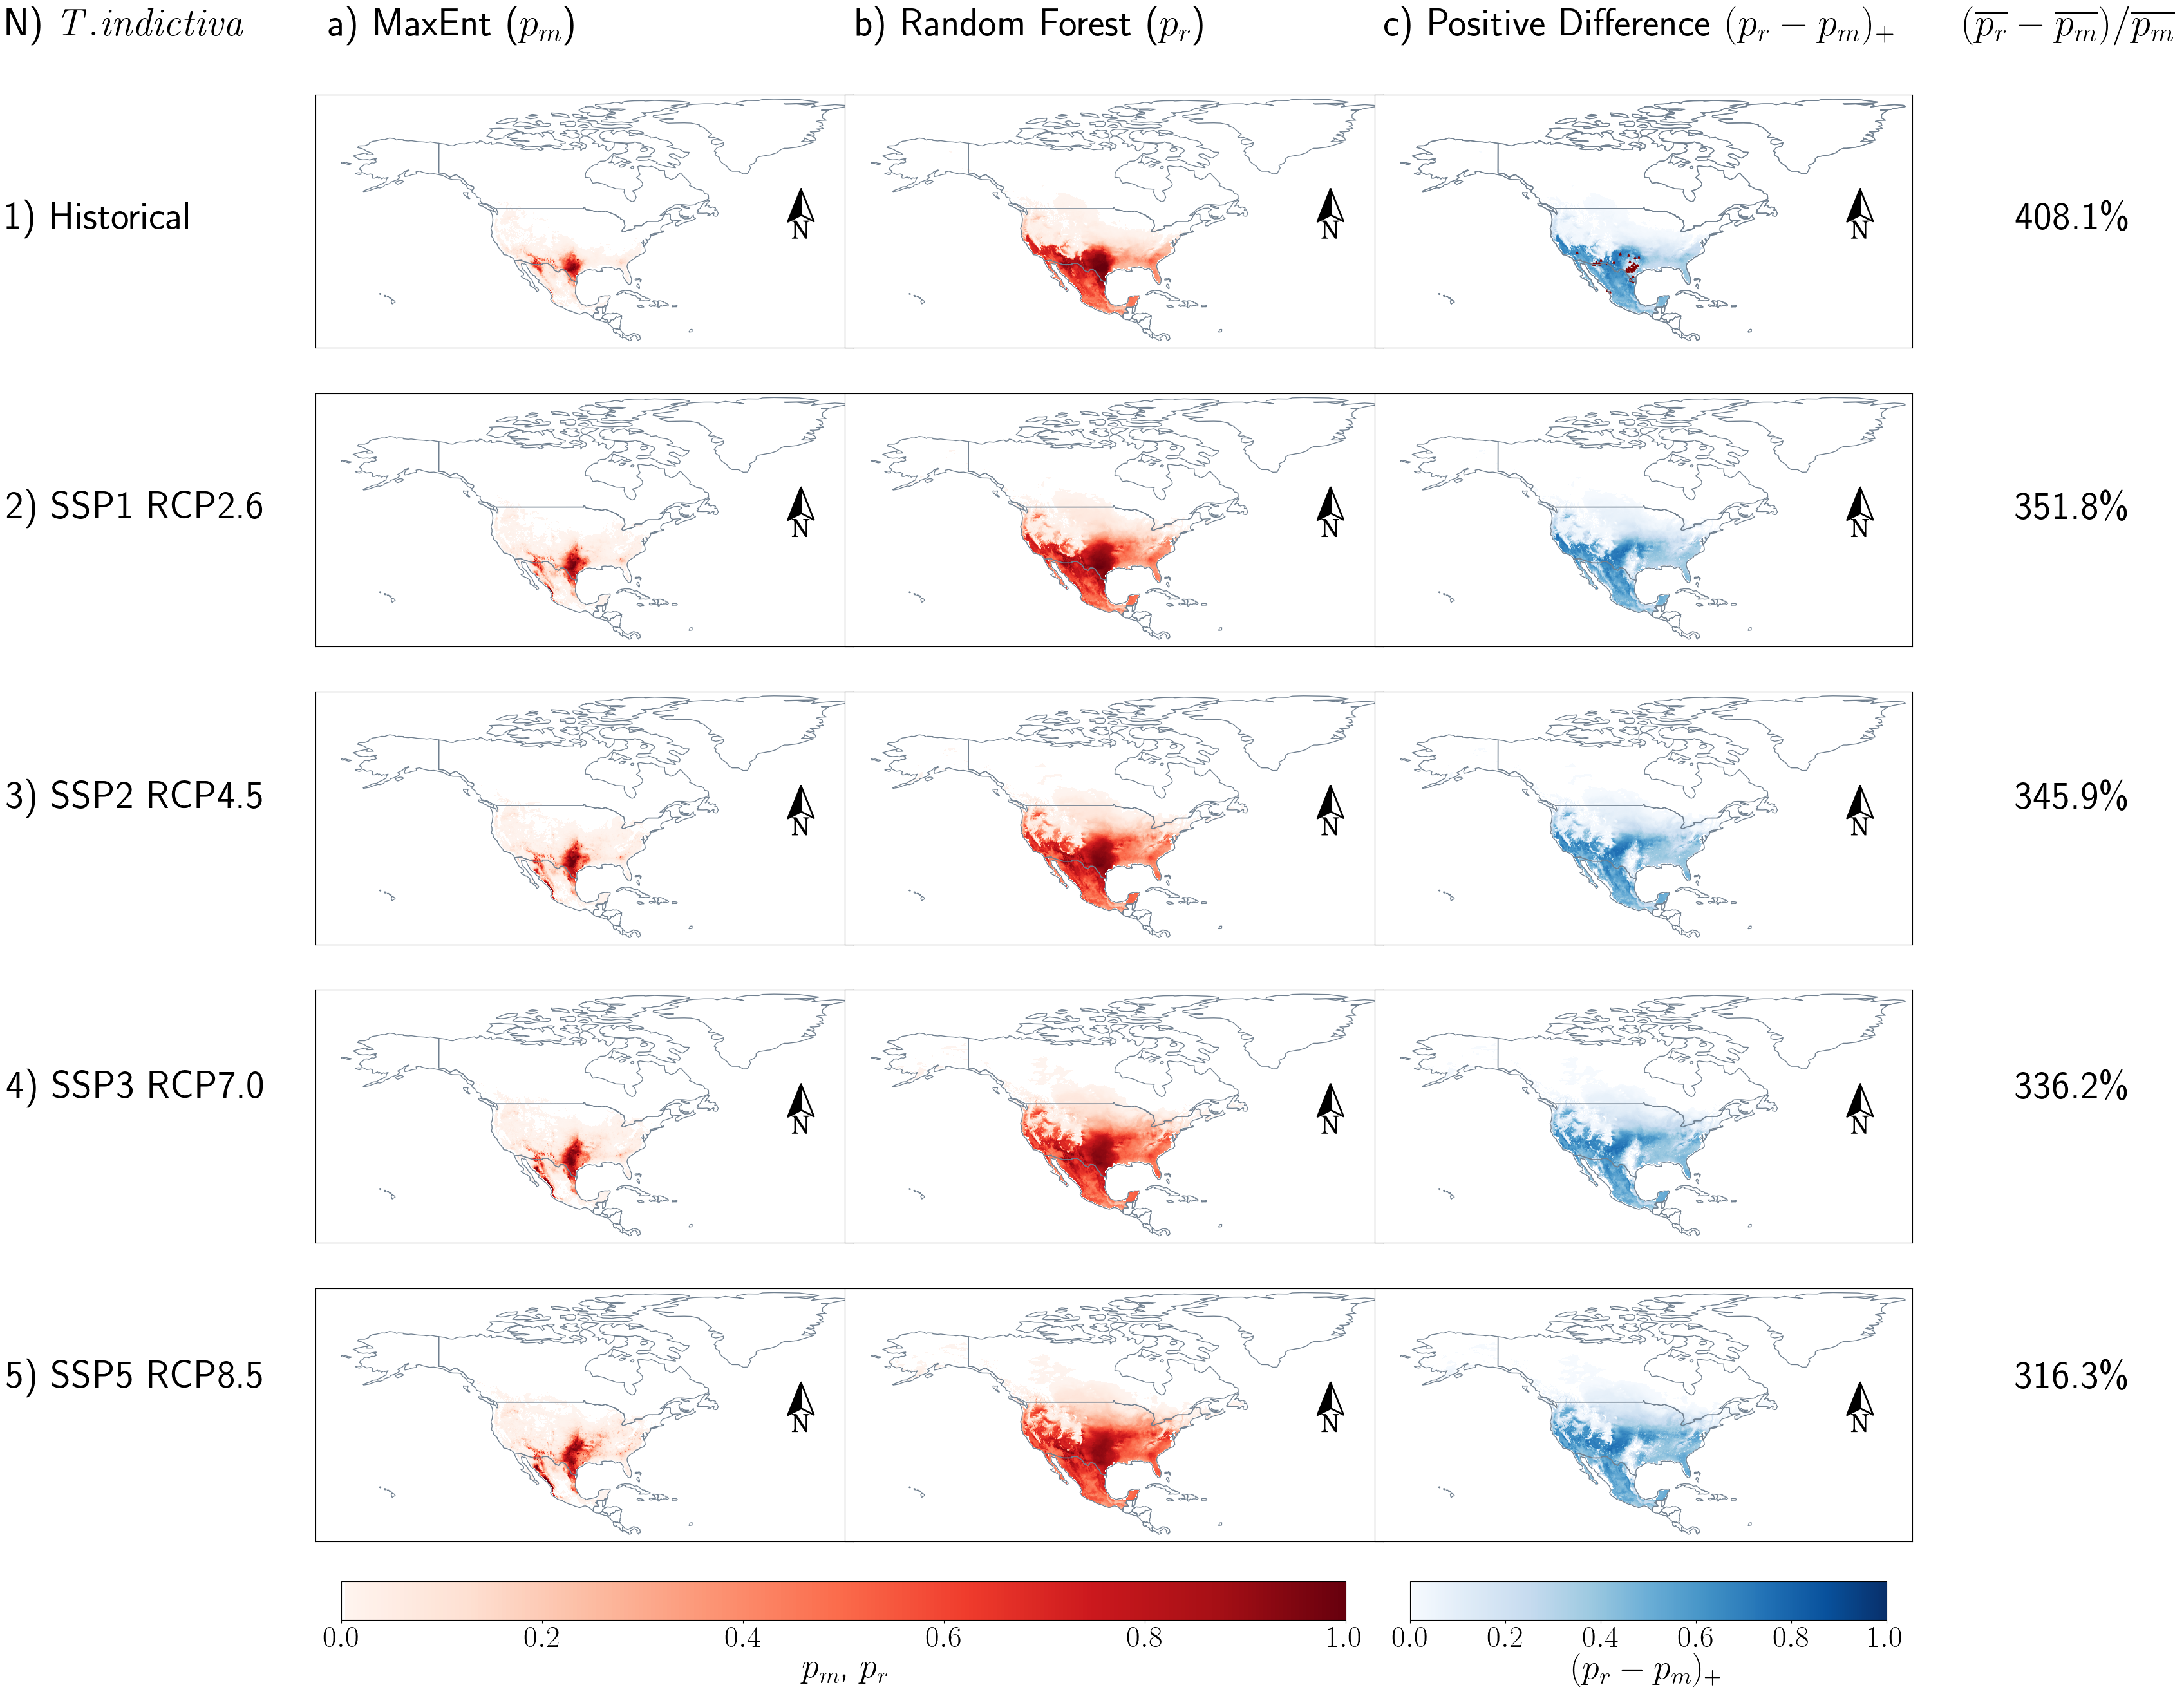

In [ ]:
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
north_america = world[world['continent'] == 'North America']

# Enable LaTeX rendering in Matplotlib
this_fontsize = 44
xlim = [-180,-10]
ylim = [5,85]
#sp_rarefied_name_list = ['san','pro','ger','dim','rub','rec','mex','maz','neo','lon','lec','ind']
#bug_name_list = ['San','Pro','Ger','Dim','Rub','Rec','Mex','Maz','Neo','Lon','Lec','Ind']
raster_save_list = ["historical_predict_allinput_","ssp126_predict_allinput_","ssp245_predict_allinput_","ssp370_predict_allinput_","ssp585_predict_allinput_"]
diff_raster_save_list = ["diff_historical.tif","diff_ssp126.tif","diff_ssp245.tif","diff_ssp370.tif","diff_ssp585.tif"]
#sp_rarefied_name_list_full = ['T. sanguisuga','T. protracta','T. gerstaeckeri','T. dimidiata','T. rubida',' T. recurva','T. mexicana','T. mazzottii','T. neotomae','T. longipennis',' P. lecticularia',' T. indictiva']
#label_list = ['A','B','C','D','E','F','G','H','I','J','K','L','M','N']
for j in [13]:#range(len(bug_short_name_list)):

    this_bug = bug_short_name_list[j]
    print(this_bug)
    fig, ax = plt.subplots(5,3, figsize=(40,30))
    plt.rcParams['text.usetex'] = True
    for i in range(15):
        
        ax_0 = i // 3
        ax_1 = i % 3

        
        north_america.boundary.plot(ax=ax[ax_0,ax_1], color = 'slategrey',linewidth=1,figsize=(6,5))


        # maxent
        if ax_1 == 0:
            name_for_saving = dir_top_maxent + '/' + this_bug+"/result/output_raster/all_input/"+ raster_save_list[ax_0] + this_bug + '.tif'
            predict_plot_final = rio.open(name_for_saving)
            show(predict_plot_final,cmap=new_red,ax=ax[ax_0,ax_1],vmin=0, vmax=1)

        # rf
        if ax_1 == 1:
            name_for_saving = dir_top_rf + '/' + this_bug+"/result/output_raster/all_input/"+ raster_save_list[ax_0] + this_bug + '.tif'
            predict_plot_final = rio.open(name_for_saving)
            show(predict_plot_final,cmap=new_red,ax=ax[ax_0,ax_1],vmin=0, vmax=1)

        # difference + 
        if ax_1 == 2:
            name_for_saving = dir_diff + '/' + this_bug + '/'+ diff_raster_save_list[ax_0]
            predict_plot_final = rio.open(name_for_saving)
            show(predict_plot_final,cmap=new_blue,ax=ax[ax_0,ax_1],vmin=0, vmax=1)

        # observation
        if ax_1 == 2 and ax_0 == 0:
                sp_path_filter = "/your_path/Documents/GitHub/Clean_species_data/data/spthin/"+bug_short_name_list[j]+'.csv'
                pre_select_filter = pd.read_csv(sp_path_filter)
                north_america.boundary.plot(ax=ax[ax_0,ax_1], color = 'slategrey',linewidth=1,figsize=(6,5))
                gdf4 = gpd.GeoDataFrame(pre_select_filter, geometry=gpd.points_from_xy(pre_select_filter.DecimalLongitude, pre_select_filter.DecimalLatitude))
                gdf4.plot(marker='^', ax=ax[ax_0,ax_1], color='maroon', markersize=5)

        
        ax[ax_0,ax_1].set_aspect('equal')
        ax[ax_0,ax_1].set_xlim(xlim)
        ax[ax_0,ax_1].set_ylim(ylim)
        ax[ax_0,ax_1].tick_params(left = False, right = False , labelleft = False ,labelbottom = False, bottom = False)
        add_north_arrow(ax=ax[ax_0,ax_1], scale=.75, xlim_pos=.9025, ylim_pos=.5, color='#000', text_scaler=4, text_yT=-1.25)
        
    plt.gcf().text(0.08, 0.90, label_list[j] + ') ' + r'$\it{%s}$' % sp_rarefied_name_list_full[j], fontsize=this_fontsize,weight='bold')
    plt.gcf().text(0.08, 0.80, '1) Historical', fontsize=this_fontsize)
    plt.gcf().text(0.08, 0.65, '2) SSP1 RCP2.6', fontsize=this_fontsize)
    plt.gcf().text(0.08, 0.50, '3) SSP2 RCP4.5', fontsize=this_fontsize)
    plt.gcf().text(0.08, 0.35, '4) SSP3 RCP7.0', fontsize=this_fontsize)
    plt.gcf().text(0.08, 0.20, '5) SSP5 RCP8.5', fontsize=this_fontsize)
    plt.gcf().text(0.205, 0.90, 'a) MaxEnt ('+"$p_{m}$"+')', fontsize=this_fontsize)
    plt.gcf().text(0.41, 0.90, 'b) Random Forest ('+"$p_{r}$"+')', fontsize=this_fontsize)
    plt.gcf().text(0.615, 0.90, 'c) Positive Difference '+'$(p_{r}-p_{m})_+$', fontsize=this_fontsize)

    
    plt.subplots_adjust(hspace=0.015)
    plt.subplots_adjust(wspace=-0.015)
    plt.subplots_adjust(left=0.2,right=0.82)

    diff_file_path = dir_diff +  '/' + this_bug + '/'+ "/sum_results.csv"   
    diff_df = pd.read_csv(diff_file_path)
    plt.gcf().text(0.84, 0.90, r'$(\overline{p_{r}}-\overline{p_{m}})/\overline{p_{m}}$', fontsize=this_fontsize)
    plt.gcf().text(0.86, 0.80, '%.1f'%(100*(diff_df['sum_diff_raster_historical'])/diff_df['sum_maxent_raster_historical']) + '\%', fontsize=this_fontsize)
    plt.gcf().text(0.86, 0.65, '%.1f'%(100*(diff_df['sum_diff_raster_ssp126'])/diff_df['sum_maxent_raster_ssp126']) + '\%', fontsize=this_fontsize)
    plt.gcf().text(0.86, 0.50, '%.1f'%(100*(diff_df['sum_diff_raster_ssp245'])/diff_df['sum_maxent_raster_ssp245']) + '\%', fontsize=this_fontsize)
    plt.gcf().text(0.86, 0.35, '%.1f'%(100*(diff_df['sum_diff_raster_ssp370'])/diff_df['sum_maxent_raster_ssp370']) + '\%', fontsize=this_fontsize)
    plt.gcf().text(0.86, 0.20, '%.1f'%(100*(diff_df['sum_diff_raster_ssp585'])/diff_df['sum_maxent_raster_ssp585']) + '\%', fontsize=this_fontsize)
    
    # # subplot for colorbar
    ax2 =fig.add_axes([0.21,0.08,0.39,0.02])
    cb2 = mpl.colorbar.ColorbarBase(ax2, orientation='horizontal', cmap=new_red)
    cb2.set_label("$p_{m}$"+', '+"$p_{r}$", labelpad=0, size=this_fontsize-5)
    cb2.ax.tick_params(labelsize=this_fontsize-10)
    # # subplot for colorbar
    norm3 = Normalize(vmin=0, vmax=1)
    ax3 =fig.add_axes([0.625,0.08,0.185,0.02])
    cb3 = mpl.colorbar.ColorbarBase(ax3, orientation='horizontal', cmap=new_blue,norm=norm3)
    cb3.set_label("$(p_{r}-p_{m})_+$", labelpad=0, size=this_fontsize-5)
    cb3.ax.tick_params(labelsize=this_fontsize-10)


    
    #'T. dimidiata','T. gerstaeckeri','T. protracta','T. sanguisuga'
    plt.savefig(dir_saving_plot_path+'/'+this_bug+'_3plots.png',dpi=100)
    #plt.clf()

/Users/liting/Documents/GitHub/r_chagasM/output/figures/final_plot/difference/san/sum_results.csv
/Users/liting/Documents/GitHub/Clean_species_data/data/spthin/san.csv
/Users/liting/Documents/GitHub/r_chagasM/output/figures/final_plot/difference/dim/sum_results.csv
/Users/liting/Documents/GitHub/Clean_species_data/data/spthin/dim.csv
/Users/liting/Documents/GitHub/r_chagasM/output/figures/final_plot/difference/ger/sum_results.csv
/Users/liting/Documents/GitHub/Clean_species_data/data/spthin/ger.csv
/Users/liting/Documents/GitHub/r_chagasM/output/figures/final_plot/difference/pro/sum_results.csv
/Users/liting/Documents/GitHub/Clean_species_data/data/spthin/pro.csv
/Users/liting/Documents/GitHub/r_chagasM/output/figures/final_plot/difference/lon/sum_results.csv
/Users/liting/Documents/GitHub/Clean_species_data/data/spthin/lon.csv
/Users/liting/Documents/GitHub/r_chagasM/output/figures/final_plot/difference/rub/sum_results.csv
/Users/liting/Documents/GitHub/Clean_species_data/data/spthin/

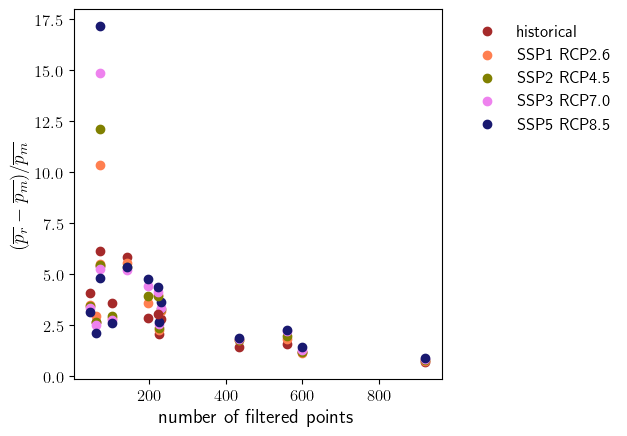

In [ ]:
# Enable LaTeX rendering in Matplotlib
this_fontsize = 14
raster_save_list = ["historical_predict_allinput_","ssp126_predict_allinput_","ssp245_predict_allinput_","ssp370_predict_allinput_","ssp585_predict_allinput_"]
diff_raster_save_list = ["diff_historical.tif","diff_ssp126.tif","diff_ssp245.tif","diff_ssp370.tif","diff_ssp585.tif"]

for j in range(len(bug_short_name_list)):
    diff_file_path = dir_diff +  '/' + bug_short_name_list[j] + "/sum_results.csv"   
    diff_df = pd.read_csv(diff_file_path)
    print(diff_file_path)

    sp_path_filter = "/your_path/Documents/GitHub/Clean_species_data/data/spthin/"+bug_short_name_list[j]+'.csv'
    print(sp_path_filter)
    pre_select_filter = pd.read_csv(sp_path_filter)
    gdf4 = gpd.GeoDataFrame(pre_select_filter, geometry=gpd.points_from_xy(pre_select_filter.DecimalLongitude, pre_select_filter.DecimalLatitude))
    gdf4.plot(marker='^', ax=ax[ax_0,ax_1], color='maroon', markersize=50)
    number_points_filtered = len(pre_select_filter)
    if j==len(bug_name_list)-1:
        plt.scatter(number_points_filtered, diff_df['sum_diff_raster_historical']/diff_df['sum_maxent_raster_historical'], c='brown', marker='o',label='historical')
        plt.scatter(number_points_filtered, diff_df['sum_diff_raster_ssp126']/diff_df['sum_maxent_raster_ssp126'], c='coral', marker='o',label='SSP1 RCP2.6')
        plt.scatter(number_points_filtered, diff_df['sum_diff_raster_ssp245']/diff_df['sum_maxent_raster_ssp245'], c='olive', marker='o',label='SSP2 RCP4.5')
        plt.scatter(number_points_filtered, diff_df['sum_diff_raster_ssp370']/diff_df['sum_maxent_raster_ssp370'], c='violet', marker='o',label='SSP3 RCP7.0')
        plt.scatter(number_points_filtered, diff_df['sum_diff_raster_ssp585']/diff_df['sum_maxent_raster_ssp585'], c='midnightblue', marker='o',label='SSP5 RCP8.5')
    else:
        plt.scatter(number_points_filtered, diff_df['sum_diff_raster_historical']/diff_df['sum_maxent_raster_historical'], c='brown', marker='o')
        plt.scatter(number_points_filtered, diff_df['sum_diff_raster_ssp126']/diff_df['sum_maxent_raster_ssp126'], c='coral', marker='o')
        plt.scatter(number_points_filtered, diff_df['sum_diff_raster_ssp245']/diff_df['sum_maxent_raster_ssp245'], c='olive', marker='o')
        plt.scatter(number_points_filtered, diff_df['sum_diff_raster_ssp370']/diff_df['sum_maxent_raster_ssp370'], c='violet', marker='o')
        plt.scatter(number_points_filtered, diff_df['sum_diff_raster_ssp585']/diff_df['sum_maxent_raster_ssp585'], c='midnightblue', marker='o')

plt.subplots_adjust(right=0.7)
plt.legend(bbox_to_anchor=(1.5, 1),frameon=False,fontsize=this_fontsize-2)
plt.xlabel("number of filtered points",fontsize=this_fontsize)
plt.ylabel(r'$(\overline{p_{r}}-\overline{p_{m}})/\overline{p_{m}}$',fontsize=this_fontsize)
plt.tick_params('both',labelsize=this_fontsize-2)
plt.savefig(dir_saving_plot_path+'/presence-percentageDifference.png',dpi=300)
